In [1]:
import mne

raw = mne.io.read_raw_edf(
    "../data/ds005931/sub-01/ses-01/ieeg/sub-01_ses-01_task-game_run-01_ieeg.edf",
    preload=True
)
print(raw.info)
print(raw.annotations.description[:20])

Extracting EDF parameters from ../data/ds005931/sub-01/ses-01/ieeg/sub-01_ses-01_task-game_run-01_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 437071  =      0.000 ...   437.071 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: POL A1-AV, POL A2-AV, POL A3-AV, POL A4-AV, POL A5-AV, POL ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 500.0 Hz
 meas_date: 2000-01-01 00:00:00 UTC
 nchan: 64
 projs: []
 sfreq: 1000.0 Hz
 subject_info: <subject_info | his_id: 0, sex: 2, first_name: No, last_name: Name, birthday: 1800-01-01>
>
['Trigger-101' 'Trigger-101' 'Trigger-101' 'Trigger-101' 'Trigger-101'
 'Trigger-101' 'Trigger-101' 'Trigger-101' 'Trigger-101' 'Trigger-101'
 'Trigger-101' 'Trigger-101' 'Trigger-101' 'Trigger-101' 'Trigger-101'
 'Trigger-101' 'Trigger-101' 'Trigger-101' 'Trigger-101' 'Trigger-101']


In [2]:
print(raw.ch_names)
print(len(raw.ch_names))
print(set(raw.get_channel_types()))

['POL A1-AV', 'POL A2-AV', 'POL A3-AV', 'POL A4-AV', 'POL A5-AV', 'POL A6-AV', 'POL A7-AV', 'POL A8-AV', 'POL A9-AV', 'POL A10-AV', 'POL A11-AV', 'POL A12-AV', 'POL A13-AV', 'POL A14-AV', 'POL A15-AV', 'POL A16-AV', 'POL A17-AV', 'POL A18-AV', 'POL A19-AV', 'POL A20-AV', 'POL A21-AV', 'POL A22-AV', 'POL A23-AV', 'POL A24-AV', 'POL A25-AV', 'POL A26-AV', 'POL A27-AV', 'POL A28-AV', 'POL A29-AV', 'POL A30-AV', 'POL A31-AV', 'POL A32-AV', 'POL A33-AV', 'POL A34-AV', 'POL A35-AV', 'POL A36-AV', 'POL A37-AV', 'POL A38-AV', 'POL A39-AV', 'POL A40-AV', 'POL A41-AV', 'POL A42-AV', 'POL A43-AV', 'POL A44-AV', 'POL A45-AV', 'POL A46-AV', 'POL A47-AV', 'POL A48-AV', 'POL A49-AV', 'POL A50-AV', 'POL A51-AV', 'POL A52-AV', 'POL A53-AV', 'POL A54-AV', 'POL A55-AV', 'POL A56-AV', 'POL A57-AV', 'POL A58-AV', 'POL A59-AV', 'POL A60-AV', 'POL A61-AV', 'POL A62-AV', 'POL A63-AV', 'POL A64-AV']
64
{'eeg'}


In [3]:
for ann in raw.annotations[:10]:
    print(ann)

OrderedDict({'onset': np.float64(55.701), 'duration': np.float64(0.0), 'description': np.str_('Trigger-101'), 'orig_time': datetime.datetime(2000, 1, 1, 0, 0, tzinfo=datetime.timezone.utc), 'extras': {}})
OrderedDict({'onset': np.float64(57.282), 'duration': np.float64(0.0), 'description': np.str_('Trigger-101'), 'orig_time': datetime.datetime(2000, 1, 1, 0, 0, tzinfo=datetime.timezone.utc), 'extras': {}})
OrderedDict({'onset': np.float64(59.631), 'duration': np.float64(0.0), 'description': np.str_('Trigger-101'), 'orig_time': datetime.datetime(2000, 1, 1, 0, 0, tzinfo=datetime.timezone.utc), 'extras': {}})
OrderedDict({'onset': np.float64(60.784), 'duration': np.float64(0.0), 'description': np.str_('Trigger-101'), 'orig_time': datetime.datetime(2000, 1, 1, 0, 0, tzinfo=datetime.timezone.utc), 'extras': {}})
OrderedDict({'onset': np.float64(61.861), 'duration': np.float64(0.0), 'description': np.str_('Trigger-101'), 'orig_time': datetime.datetime(2000, 1, 1, 0, 0, tzinfo=datetime.timez

In [4]:
import numpy as np
print(np.unique(raw.annotations.description))

['Trigger-101']


In [5]:
import numpy as np

onsets = raw.annotations.onset
print(f"Total triggers: {len(onsets)}")
print(f"Recording duration: {raw.times[-1]:.1f} sec")

intervals = np.diff(onsets)
print(f"Median inter-trigger interval: {np.median(intervals):.3f} sec")
print(f"Min: {intervals.min():.3f} sec, Max: {intervals.max():.3f} sec")

Total triggers: 181
Recording duration: 437.1 sec
Median inter-trigger interval: 1.077 sec
Min: 0.554 sec, Max: 18.090 sec


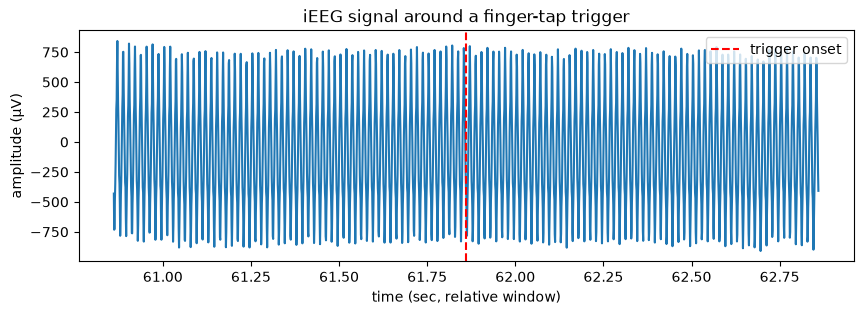

In [6]:
import matplotlib.pyplot as plt

onset = raw.annotations.onset[4]
sfreq = raw.info['sfreq']
start_sample = int((onset - 1.0) * sfreq)   # 1 sec before
end_sample = int((onset + 1.0) * sfreq)     # 1 sec after

data, times = raw[0, start_sample:end_sample]  # channel 0, POL A1-AV
plt.figure(figsize=(10, 3))
plt.plot(times, data[0] * 1e6)  # convert to microvolts
plt.axvline(times[int(1.0*sfreq)], color='red', linestyle='--', label='trigger onset')
plt.xlabel('time (sec, relative window)')
plt.ylabel('amplitude (µV)')
plt.legend()
plt.title('iEEG signal around a finger-tap trigger')
plt.show()

In [7]:
import csv

with open("../data/ds005931/sub-01/ses-01/ieeg/sub-01_ses-01_task-game_run-01_channels.tsv") as f:
    reader = csv.DictReader(f, delimiter="\t")
    for row in reader:
        if row["name"] == "A1":
            print(row)

{'name': 'A1', 'type': 'ECOG', 'units': 'µV', 'low_cutoff': '0.016', 'high_cutoff': '300', 'reference': 'n/a', 'group': 'n/a', 'sampling_frequency': '1000', 'description': 'n/a', 'notch': 'n/a', 'status': 'bad', 'status_description': 'artifact'}
